In [1]:
import json
import os
import random
import warnings
from copy import deepcopy
from typing import Any, Dict, List, Optional, Tuple

warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split

from transformers import (
    AutoTokenizer,
    AutoModel,
    AdamW,
    get_cosine_schedule_with_warmup,
)

try:
    from seqeval.metrics import classification_report as ner_report
    HAS_SEQEVAL = True
except ImportError:
    print("seqeval not found — NER per-class F1 will be skipped.")
    HAS_SEQEVAL = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(DEVICE_TYPE)
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")


Device : cuda
PyTorch: 2.5.1+cu124


In [ ]:
NER_TAGS = ["O", "B-PERSON", "I-PERSON"]
NER2ID   = {t: i for i, t in enumerate(NER_TAGS)}
ID2NER   = {i: t for t, i in NER2ID.items()}
NER_PAD_ID = -100

ATTRIBUTES = [
    "goals", "assists", "clean_sheets", "trophies", "individual_awards",
    "caps", "ratings", "speed", "dribbling", "passing", "defending",
    "consistency", "leadership", "impact", "other"
]
ATTR2ID = {a: i for i, a in enumerate(ATTRIBUTES)}
ID2ATTR = {i: a for a, i in ATTR2ID.items()}

RELATIONS = ["greater_than", "less_than", "equal", "subjective", "causal", "contradicts"]
REL2ID    = {r: i for i, r in enumerate(RELATIONS)}
ID2REL    = {i: r for r, i in REL2ID.items()}

CLAIM_TYPES = ["statistical", "factual", "opinion", "hypothetical", "analogy"]
CT2ID       = {c: i for i, c in enumerate(CLAIM_TYPES)}
ID2CT       = {i: c for c, i in CT2ID.items()}

STANCES   = ["support", "attack", "concession", "neutral"]
STANCE2ID = {s: i for i, s in enumerate(STANCES)}
ID2STANCE = {i: s for s, i in STANCE2ID.items()}

MODEL_NAME      = "microsoft/deberta-v3-base"
MAX_LENGTH      = 192
BATCH_SIZE      = 8
ACCUM_STEPS     = 2
EPOCHS          = 50
LR              = 2e-5
DROPOUT         = 0.1
WARMUP_RATIO    = 0.06
MLP_HIDDEN      = 256
LABEL_SMOOTHING = 0.1

LOSS_WEIGHTS = {
    "ner"       : 2.5,   
    "attribute" : 1.0,
    "relation"  : 1.0,
    "claim_type": 1.0,
    "stance"    : 0.8,
}

print(f"NER tags   ({len(NER_TAGS)}): {NER_TAGS}")
print(f"Attributes ({len(ATTRIBUTES)}): {ATTRIBUTES}")
print(f"Relations  ({len(RELATIONS)}): {RELATIONS}")
print(f"ClaimTypes ({len(CLAIM_TYPES)}): {CLAIM_TYPES}")
print(f"Stances    ({len(STANCES)}): {STANCES}")

NER tags   (3): ['O', 'B-PERSON', 'I-PERSON']
Attributes (15): ['goals', 'assists', 'clean_sheets', 'trophies', 'individual_awards', 'caps', 'ratings', 'speed', 'dribbling', 'passing', 'defending', 'consistency', 'leadership', 'impact', 'other']
Relations  (6): ['greater_than', 'less_than', 'equal', 'subjective', 'causal', 'contradicts']
ClaimTypes (5): ['statistical', 'factual', 'opinion', 'hypothetical', 'analogy']
Stances    (4): ['support', 'attack', 'concession', 'neutral']


In [3]:
RAW_DATA = [
    {"id": 1,  "speaker": "A", "text": "Messi has won eight Ballon d'Or awards, more than any player in history.",
     "entities": ["Messi"],
     "attribute": "individual_awards", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 2,  "speaker": "B", "text": "Ronaldo scored over 900 career goals, surpassing every other footballer.",
     "entities": ["Ronaldo"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 3,  "speaker": "A", "text": "Messi provided more assists in La Liga than any other player in history.",
     "entities": ["Messi"],
     "attribute": "assists", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 4,  "speaker": "B", "text": "Mbappe's recorded top speed of 38 km/h makes him the fastest player in the modern era.",
     "entities": ["Mbappe"],
     "attribute": "speed", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 5,  "speaker": "A", "text": "Lewandowski's Bundesliga goal tally exceeds that of Muller in consecutive seasons.",
     "entities": ["Lewandowski", "Muller"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 6,  "speaker": "B", "text": "Mbappe has fewer career goals than Ronaldo did at the same age.",
     "entities": ["Mbappe", "Ronaldo"],
     "attribute": "goals", "relation": "less_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 7,  "speaker": "A", "text": "Benzema registered fewer assists than Messi in Champions League history.",
     "entities": ["Benzema", "Messi"],
     "attribute": "assists", "relation": "less_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 8,  "speaker": "B", "text": "Salah's sprint speed is slightly below Mbappe's peak recorded velocity.",
     "entities": ["Salah", "Mbappe"],
     "attribute": "speed", "relation": "less_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 9,  "speaker": "A", "text": "Modric received a lower WhoScored rating than De Bruyne last season.",
     "entities": ["Modric", "De Bruyne"],
     "attribute": "ratings", "relation": "less_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 10, "speaker": "B", "text": "Haaland scored fewer Champions League goals than Messi by end of 2023.",
     "entities": ["Haaland", "Messi"],
     "attribute": "goals", "relation": "less_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 11, "speaker": "A", "text": "Both Messi and Ronaldo have won four Champions League titles each.",
     "entities": ["Messi", "Ronaldo"],
     "attribute": "trophies", "relation": "equal", "claim_type": "factual", "stance": "neutral"},
    {"id": 12, "speaker": "B", "text": "Xavi and Iniesta have an identical number of World Cup caps for Spain.",
     "entities": ["Xavi", "Iniesta"],
     "attribute": "caps", "relation": "equal", "claim_type": "factual", "stance": "neutral"},
    {"id": 13, "speaker": "A", "text": "De Bruyne's key passes per game equalled Messi's in 2019-20.",
     "entities": ["De Bruyne", "Messi"],
     "attribute": "passing", "relation": "equal", "claim_type": "statistical", "stance": "neutral"},
    {"id": 14, "speaker": "B", "text": "Brazil and Germany have each won the FIFA World Cup four times.",
     "entities": [],
     "attribute": "trophies", "relation": "equal", "claim_type": "factual", "stance": "neutral"},
    {"id": 15, "speaker": "A", "text": "Messi is simply the most graceful footballer ever to play the game.",
     "entities": ["Messi"],
     "attribute": "other", "relation": "subjective", "claim_type": "opinion", "stance": "support"},
    {"id": 16, "speaker": "B", "text": "Ronaldo's dedication and work ethic make him the greatest of all time.",
     "entities": ["Ronaldo"],
     "attribute": "consistency", "relation": "subjective", "claim_type": "opinion", "stance": "support"},
    {"id": 17, "speaker": "A", "text": "I believe Neymar is more entertaining to watch than Mbappe on any given day.",
     "entities": ["Neymar", "Mbappe"],
     "attribute": "other", "relation": "subjective", "claim_type": "opinion", "stance": "support"},
    {"id": 18, "speaker": "B", "text": "From a pure aesthetics standpoint, Zidane was a more beautiful player than Ronaldo.",
     "entities": ["Zidane", "Ronaldo"],
     "attribute": "other", "relation": "subjective", "claim_type": "opinion", "stance": "attack"},
    {"id": 19, "speaker": "A", "text": "I admit Ronaldo has more international goals than Messi, but club-level Messi wins.",
     "entities": ["Ronaldo", "Messi"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "factual", "stance": "concession"},
    {"id": 20, "speaker": "B", "text": "Sure, Messi has more Ballon d'Ors, but trophies with the national team tell a different story.",
     "entities": ["Messi"],
     "attribute": "individual_awards", "relation": "greater_than", "claim_type": "factual", "stance": "concession"},
    {"id": 21, "speaker": "A", "text": "If Messi had played for a top-five national side, he would have won multiple World Cups.",
     "entities": ["Messi"],
     "attribute": "trophies", "relation": "greater_than", "claim_type": "hypothetical", "stance": "support"},
    {"id": 22, "speaker": "B", "text": "Had Ronaldo stayed at Real Madrid, he would have surpassed his Champions League record.",
     "entities": ["Ronaldo"],
     "attribute": "trophies", "relation": "greater_than", "claim_type": "hypothetical", "stance": "support"},
    {"id": 23, "speaker": "A", "text": "Messi in football is what Jordan was in basketball — the undisputed peak.",
     "entities": ["Messi", "Jordan"],
     "attribute": "impact", "relation": "equal", "claim_type": "analogy", "stance": "support"},
    {"id": 24, "speaker": "B", "text": "Ronaldo's consistency over 20 years is like Federer's dominance in tennis.",
     "entities": ["Ronaldo", "Federer"],
     "attribute": "consistency", "relation": "equal", "claim_type": "analogy", "stance": "support"},
    {"id": 25, "speaker": "A", "text": "Messi's superior dribbling caused Barcelona to win three trebles in a decade.",
     "entities": ["Messi"],
     "attribute": "dribbling", "relation": "causal", "claim_type": "opinion", "stance": "support"},
    {"id": 26, "speaker": "B", "text": "Ronaldo's physicality and finishing drove Juventus to win Serie A five seasons running.",
     "entities": ["Ronaldo"],
     "attribute": "goals", "relation": "causal", "claim_type": "opinion", "stance": "support"},
    {"id": 27, "speaker": "A", "text": "You claimed Ronaldo scored 800 goals but FIFA records show only 720 verified.",
     "entities": ["Ronaldo"],
     "attribute": "goals", "relation": "contradicts", "claim_type": "factual", "stance": "attack"},
    {"id": 28, "speaker": "A", "text": "Well, statistically speaking, Messi's goals-per-game ratio beats Lewandowski's.",
     "entities": ["Messi", "Lewandowski"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 29, "speaker": "B", "text": "You can't deny it — Ronaldo has bagged more hat-tricks than anyone else in history.",
     "entities": ["Ronaldo"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 30, "speaker": "A", "text": "Honestly, Neymar and Mbappe are equally skilled in tight dribbling situations.",
     "entities": ["Neymar", "Mbappe"],
     "attribute": "dribbling", "relation": "equal", "claim_type": "opinion", "stance": "neutral"},
    {"id": 31, "speaker": "B", "text": "Let's be real — Buffon kept more clean sheets than Casillas in their peak years.",
     "entities": ["Buffon", "Casillas"],
     "attribute": "clean_sheets", "relation": "greater_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 32, "speaker": "A", "text": "Benzema won the Ballon d'Or in 2022 — that's an objective, verified fact.",
     "entities": ["Benzema"],
     "attribute": "individual_awards", "relation": "equal", "claim_type": "factual", "stance": "neutral"},
    {"id": 33, "speaker": "B", "text": "Messi and Pele share the same number of Copa America titles — one each.",
     "entities": ["Messi", "Pele"],
     "attribute": "trophies", "relation": "equal", "claim_type": "factual", "stance": "neutral"},
    {"id": 34, "speaker": "A", "text": "Ronaldo's international caps for Portugal are fewer than Messi's for Argentina.",
     "entities": ["Ronaldo", "Messi"],
     "attribute": "caps", "relation": "less_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 35, "speaker": "B", "text": "Pele's impact on football culture surpasses everyone else's in my view.",
     "entities": ["Pele"],
     "attribute": "impact", "relation": "subjective", "claim_type": "opinion", "stance": "support"},
    {"id": 36, "speaker": "A", "text": "Neymar's dribbling success rate is higher than Salah's across comparable seasons.",
     "entities": ["Neymar", "Salah"],
     "attribute": "dribbling", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 37, "speaker": "B", "text": "Rooney won fewer Ballon d'Or awards compared to both Messi and Ronaldo combined.",
     "entities": ["Rooney", "Messi", "Ronaldo"],
     "attribute": "individual_awards", "relation": "less_than", "claim_type": "statistical", "stance": "neutral"},
    {"id": 38, "speaker": "A", "text": "Messi's average Sofascore rating of 8.1 is higher than Ronaldo's 7.9 this season.",
     "entities": ["Messi", "Ronaldo"],
     "attribute": "ratings", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 39, "speaker": "B", "text": "Messi's leadership during the 2022 World Cup final was unmatched.",
     "entities": ["Messi"],
     "attribute": "leadership", "relation": "subjective", "claim_type": "opinion", "stance": "support"},
    {"id": 40, "speaker": "A", "text": "Ronaldo has won more UEFA Champions League titles than any other outfield player.",
     "entities": ["Ronaldo"],
     "attribute": "trophies", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 41, "speaker": "B", "text": "Despite winning the Premier League, Salah has never lifted the FA Cup.",
     "entities": ["Salah"],
     "attribute": "trophies", "relation": "less_than", "claim_type": "factual", "stance": "attack"},
    {"id": 42, "speaker": "A", "text": "Iniesta's passing accuracy of 93% in the 2010 World Cup final was record-breaking.",
     "entities": ["Iniesta"],
     "attribute": "passing", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 43, "speaker": "B", "text": "Thiago Silva's defending record at PSG is unmatched by any other European centre-back.",
     "entities": ["Thiago Silva"],
     "attribute": "defending", "relation": "greater_than", "claim_type": "opinion", "stance": "support"},
    {"id": 44, "speaker": "A", "text": "Gyokeres scored more goals than Ekitike in the 2023-24 Europa League campaign.",
     "entities": ["Gyokeres", "Ekitike"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "statistical", "stance": "support"},
    {"id": 45, "speaker": "B", "text": "Vinicius Jr's dribbles completed per 90 min beat Mbappe's in La Liga 2022-23.",
     "entities": ["Vinicius Jr", "Mbappe"],
     "attribute": "dribbling", "relation": "greater_than", "claim_type": "statistical", "stance": "attack"},
    {"id": 46, "speaker": "A", "text": "Buffon and Casillas have the same number of FIFA World Cup Golden Glove awards.",
     "entities": ["Buffon", "Casillas"],
     "attribute": "individual_awards", "relation": "equal", "claim_type": "factual", "stance": "neutral"},
    {"id": 47, "speaker": "B", "text": "If Messi had Ronaldo's physicality, he would never have had injury problems.",
     "entities": ["Messi", "Ronaldo"],
     "attribute": "consistency", "relation": "causal", "claim_type": "hypothetical", "stance": "attack"},
    {"id": 48, "speaker": "A", "text": "Messi's impact at Inter Miami is like Beckham's at LA Galaxy — transformative.",
     "entities": ["Messi", "Beckham"],
     "attribute": "impact", "relation": "equal", "claim_type": "analogy", "stance": "support"},
    {"id": 49, "speaker": "B", "text": "You said Messi won 7 Ballon d'Ors before 2020, but the actual count was 6.",
     "entities": ["Messi"],
     "attribute": "individual_awards", "relation": "contradicts", "claim_type": "factual", "stance": "attack"},
    {"id": 50, "speaker": "A", "text": "Okay, I'll grant that Ronaldo has more international goals, though his club record pales in comparison.",
     "entities": ["Ronaldo"],
     "attribute": "goals", "relation": "greater_than", "claim_type": "factual", "stance": "concession"},
]

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def _normalize_word(w: str) -> str:
    """Strip leading/trailing punctuation and possessive suffixes."""
    import re
    w = re.sub(r"[’\'']s$", "", w)   
    w = re.sub(r"[’\'']$", "", w)    
    w = re.sub(r"^[.,!?;:\'\"\(\)]+", "", w)  
    w = re.sub(r"[.,!?;:\'\"\(\)]+$", "", w)  
    return w

def generate_bio_labels(text: str, entities: List[str]) -> List[str]:
    """entities is a flat list of player name strings."""
    words  = text.split()
    labels = ["O"] * len(words)
    for ent_text in entities:
        ent_words = ent_text.split()
        ew_len    = len(ent_words)
        for i in range(len(words) - ew_len + 1):
            window = [_normalize_word(w) for w in words[i: i + ew_len]]
            if window == ent_words:
                labels[i] = "B-PERSON"
                for j in range(1, ew_len):
                    labels[i + j] = "I-PERSON"
                break
    return labels

def align_bio_with_subwords(word_labels: List[str], encoding, text: str) -> List[int]:
    token_labels = []
    previous_word_idx = None
    for word_idx in encoding.word_ids():
        if word_idx is None:
            token_labels.append(NER_PAD_ID)
        elif word_idx != previous_word_idx:
            label_str = word_labels[word_idx] if word_idx < len(word_labels) else "O"
            token_labels.append(NER2ID.get(label_str, NER2ID["O"]))
        else:
            token_labels.append(NER_PAD_ID)
        previous_word_idx = word_idx
    return token_labels

def preprocess_example(example: Dict) -> Dict:
    text     = example["text"]
    entities = example["entities"]  

    encoding = tokenizer(
        text, max_length=MAX_LENGTH, padding="max_length",
        truncation=True, return_offsets_mapping=True,
    )

    word_bio  = generate_bio_labels(text, entities)
    token_bio = align_bio_with_subwords(word_bio, encoding, text)
    token_bio = (token_bio + [NER_PAD_ID] * MAX_LENGTH)[:MAX_LENGTH]

    return {
        "id"            : example["id"],
        "speaker"       : example["speaker"],
        "text"          : text,
        "entities"      : entities,
        "input_ids"     : encoding["input_ids"],
        "attention_mask": encoding["attention_mask"],
        "ner_labels"    : token_bio,
        "attr_label"    : ATTR2ID[example["attribute"]],
        "rel_label"     : REL2ID[example["relation"]],
        "ct_label"      : CT2ID[example["claim_type"]],
        "stance_label"  : STANCE2ID[example["stance"]],
    }

PROCESSED = [preprocess_example(ex) for ex in RAW_DATA]
print(f"Preprocessed {len(PROCESSED)} examples.")

Preprocessed 50 examples.


In [5]:
class ClaimDataset(Dataset):
    def __init__(self, examples: List[Dict]):
        self.examples = examples

    def __len__(self): return len(self.examples)

    def __getitem__(self, idx):
        ex = self.examples[idx]
        return {
            "input_ids"     : torch.tensor(ex["input_ids"],      dtype=torch.long),
            "attention_mask": torch.tensor(ex["attention_mask"], dtype=torch.long),
            "ner_labels"    : torch.tensor(ex["ner_labels"],     dtype=torch.long),
            "attr_label"    : torch.tensor(ex["attr_label"],     dtype=torch.long),
            "rel_label"     : torch.tensor(ex["rel_label"],      dtype=torch.long),
            "ct_label"      : torch.tensor(ex["ct_label"],       dtype=torch.long),
            "stance_label"  : torch.tensor(ex["stance_label"],   dtype=torch.long),
        }

full_dataset = ClaimDataset(PROCESSED)
train_size   = int(0.8 * len(full_dataset))
val_size     = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

pin_mem = (DEVICE_TYPE == "cuda")
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=pin_mem)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=pin_mem)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train: 40 | Val: 10
Train batches: 5 | Val batches: 2


In [6]:
class ContextualAttentionPooling(nn.Module):
    def __init__(self, hidden: int):
        super().__init__()
        self.proj = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, 1)
        )

    def forward(self, sequence_out: torch.Tensor, attention_mask: torch.Tensor) -> torch.Tensor:
        scores  = self.proj(sequence_out).squeeze(-1)
        scores  = scores.masked_fill(attention_mask == 0, float("-inf"))
        weights = torch.softmax(scores, dim=-1).unsqueeze(-1)
        return (weights * sequence_out).sum(dim=1)


class ClassificationHead(nn.Module):
    def __init__(self, in_dim: int, mid_dim: int, out_dim: int, dropout: float):
        super().__init__()
        self.dense = nn.Linear(in_dim, mid_dim)
        self.norm  = nn.LayerNorm(mid_dim)
        self.act   = nn.GELU()
        self.drops = nn.ModuleList([nn.Dropout(dropout) for _ in range(5)])
        self.out   = nn.Linear(mid_dim, out_dim)

        nn.init.orthogonal_(self.dense.weight)
        nn.init.zeros_(self.dense.bias)
        nn.init.orthogonal_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, x):
        x = self.act(self.norm(self.dense(x)))
        logits = 0
        for drop in self.drops:
            logits += self.out(drop(x))
        return logits / len(self.drops)

In [7]:
class MultiTaskClaimModel(nn.Module):
    def __init__(
        self,
        model_name : str   = MODEL_NAME,
        dropout    : float = DROPOUT,
        mlp_hidden : int   = MLP_HIDDEN,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.encoder.gradient_checkpointing_enable()

        hidden = self.encoder.config.hidden_size

        self.dropout        = nn.Dropout(dropout)
        self.attention_pool = ContextualAttentionPooling(hidden)

        self.ner_linear  = nn.Linear(hidden, len(NER_TAGS))

        self.attr_head   = ClassificationHead(hidden, mlp_hidden, len(ATTRIBUTES),  dropout)
        self.rel_head    = ClassificationHead(hidden, mlp_hidden, len(RELATIONS),   dropout)
        self.ct_head     = ClassificationHead(hidden, mlp_hidden, len(CLAIM_TYPES), dropout)
        self.stance_head = ClassificationHead(hidden, mlp_hidden, len(STANCES),     dropout)

    def forward(
        self,
        input_ids      : torch.Tensor,
        attention_mask : torch.Tensor,
    ) -> Dict[str, torch.Tensor]:

        outputs      = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        sequence_out = outputs.last_hidden_state

        pooled = self.attention_pool(sequence_out, attention_mask)
        pooled = self.dropout(pooled)

        attr_logits   = self.attr_head(pooled)
        rel_logits    = self.rel_head(pooled)
        ct_logits     = self.ct_head(pooled)
        stance_logits = self.stance_head(pooled)

        dropped_seq   = self.dropout(sequence_out)
        ner_emissions = self.ner_linear(dropped_seq)

        return {
            "ner_emissions": ner_emissions,
            "attr"         : attr_logits,
            "rel"          : rel_logits,
            "ct"           : ct_logits,
            "stance"       : stance_logits,
        }

model = MultiTaskClaimModel().to(DEVICE)


In [ ]:
class MultiTaskLoss(nn.Module):
    def __init__(self, weights: Dict[str, float] = LOSS_WEIGHTS):
        super().__init__()
        self.w        = weights
        self.cls_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
        ner_class_weights = torch.tensor([0.1, 1.0, 1.0])
        self.ner_ce = nn.CrossEntropyLoss(
            ignore_index=NER_PAD_ID,
            weight=ner_class_weights,
        )

    def forward(self, logits, batch, model) -> Tuple[torch.Tensor, Dict]:
        self.ner_ce = self.ner_ce.to(logits["ner_emissions"].device)
        B, T, n = logits["ner_emissions"].shape
        l_ner = self.ner_ce(
            logits["ner_emissions"].view(B * T, n),
            batch["ner_labels"].view(B * T),
        )

        l_attr   = self.cls_loss(logits["attr"],   batch["attr_label"])
        l_rel    = self.cls_loss(logits["rel"],    batch["rel_label"])
        l_ct     = self.cls_loss(logits["ct"],     batch["ct_label"])
        l_stance = self.cls_loss(logits["stance"], batch["stance_label"])

        total = (
            self.w["ner"]        * l_ner    +
            self.w["attribute"]  * l_attr   +
            self.w["relation"]   * l_rel    +
            self.w["claim_type"] * l_ct     +
            self.w["stance"]     * l_stance
        )

        components = {
            "ner": l_ner, "attribute": l_attr, "relation": l_rel,
            "claim_type": l_ct, "stance": l_stance,
        }
        return total, components

criterion = MultiTaskLoss()


In [9]:
def get_param_groups(model, base_lr: float, encoder_lr_factor: float = 0.1):
    no_decay = ["bias", "LayerNorm.weight"]
    encoder_params_decay, encoder_params_nodecay = [], []
    head_params_decay, head_params_nodecay = [], []

    for name, param in model.named_parameters():
        is_encoder = name.startswith("encoder")
        is_nodecay  = any(nd in name for nd in no_decay)
        if is_encoder:
            (encoder_params_nodecay if is_nodecay else encoder_params_decay).append(param)
        else:
            (head_params_nodecay if is_nodecay else head_params_decay).append(param)

    return [
        {"params": encoder_params_decay,   "lr": base_lr * encoder_lr_factor, "weight_decay": 0.01},
        {"params": encoder_params_nodecay, "lr": base_lr * encoder_lr_factor, "weight_decay": 0.0},
        {"params": head_params_decay,      "lr": base_lr,                     "weight_decay": 0.01},
        {"params": head_params_nodecay,    "lr": base_lr,                     "weight_decay": 0.0},
    ]

param_groups  = get_param_groups(model, LR)
optimizer     = AdamW(param_groups, eps=1e-8)

total_steps   = (len(train_loader) * EPOCHS) // ACCUM_STEPS
warmup_steps  = int(total_steps * WARMUP_RATIO)

scheduler = get_cosine_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

In [10]:
scaler = torch.amp.GradScaler(DEVICE_TYPE)
TASK_KEYS = ["total", "ner", "attribute", "relation", "claim_type", "stance"]

def train_one_epoch(model, loader, optimizer, scheduler, criterion):
    model.train()
    totals = {k: 0.0 for k in TASK_KEYS}
    optimizer.zero_grad()

    for batch_idx, batch in enumerate(loader):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.amp.autocast(DEVICE_TYPE):
            logits = model(batch["input_ids"], batch["attention_mask"])
            loss, comps = criterion(logits, batch, model)
            loss = loss / ACCUM_STEPS

        scaler.scale(loss).backward()

        if (batch_idx + 1) % ACCUM_STEPS == 0 or (batch_idx + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            scheduler.step()
            optimizer.zero_grad()

        totals["total"] += loss.item() * ACCUM_STEPS
        for k, v in comps.items():
            totals[k] += v.item()

    n = len(loader)
    return {k: v / n for k, v in totals.items()}

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    totals  = {k: 0.0 for k in TASK_KEYS}
    correct = {"attribute": 0, "relation": 0, "claim_type": 0, "stance": 0}
    n_samp  = 0

    for batch in loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.amp.autocast(DEVICE_TYPE):
            logits = model(batch["input_ids"], batch["attention_mask"])
            loss, comps = criterion(logits, batch, model)

        totals["total"] += loss.item()
        for k, v in comps.items(): totals[k] += v.item()

        bs = batch["attr_label"].size(0)
        n_samp += bs
        correct["attribute"]  += (logits["attr"].argmax(-1)   == batch["attr_label"]).sum().item()
        correct["relation"]   += (logits["rel"].argmax(-1)    == batch["rel_label"]).sum().item()
        correct["claim_type"] += (logits["ct"].argmax(-1)     == batch["ct_label"]).sum().item()
        correct["stance"]     += (logits["stance"].argmax(-1) == batch["stance_label"]).sum().item()

    n = len(loader)
    metrics = {k: v / n for k, v in totals.items()}
    metrics.update({f"{k}_acc": v / n_samp for k, v in correct.items()})
    return metrics

In [11]:
history       = {"train": [], "val": []}
best_val_loss = float("inf")
best_state    = None

header = f"{'Ep':>3} | {'Train':>8} | {'Val':>8} | {'Attr':>6} | {'Rel':>6} | {'CT':>6} | {'Stance':>7}"
print(header)
print("-" * len(header))

for epoch in range(1, EPOCHS + 1):
    tr = train_one_epoch(model, train_loader, optimizer, scheduler, criterion)
    vl = evaluate(model, val_loader, criterion)

    history["train"].append(tr)
    history["val"].append(vl)

    if vl["total"] < best_val_loss:
        best_val_loss = vl["total"]
        best_state = deepcopy({k: v.cpu() for k, v in model.state_dict().items()})

    print(
        f"{epoch:>3} | {tr['total']:>8.4f} | {vl['total']:>8.4f} | "
        f"{vl['attribute_acc']:>6.3f} | {vl['relation_acc']:>6.3f} | "
        f"{vl['claim_type_acc']:>6.3f} | {vl['stance_acc']:>7.3f}"
    )

model.load_state_dict(best_state)
print(f"\nTraining complete. Best val loss: {best_val_loss:.4f}")

 Ep |    Train |      Val |   Attr |    Rel |     CT |  Stance
--------------------------------------------------------------
  1 |  10.5297 |  11.4082 |  0.000 |  0.000 |  0.100 |   0.400
  2 |  10.6640 |  11.2759 |  0.000 |  0.000 |  0.100 |   0.400
  3 |  10.3341 |  10.9799 |  0.000 |  0.000 |  0.100 |   0.400
  4 |  10.0954 |  10.7985 |  0.000 |  0.000 |  0.100 |   0.400
  5 |   9.8884 |  10.4307 |  0.000 |  0.100 |  0.100 |   0.400
  6 |   9.5944 |  10.1661 |  0.000 |  0.200 |  0.100 |   0.400
  7 |   9.3393 |   9.9412 |  0.000 |  0.200 |  0.100 |   0.400
  8 |   9.1718 |   9.6379 |  0.000 |  0.200 |  0.100 |   0.400
  9 |   8.8297 |   9.4376 |  0.000 |  0.200 |  0.200 |   0.400
 10 |   8.6714 |   9.2594 |  0.300 |  0.200 |  0.200 |   0.400
 11 |   8.3637 |   9.0853 |  0.300 |  0.200 |  0.200 |   0.400
 12 |   8.2900 |   8.9304 |  0.300 |  0.200 |  0.200 |   0.400
 13 |   8.0721 |   8.7958 |  0.300 |  0.200 |  0.300 |   0.400
 14 |   7.8627 |   8.6703 |  0.300 |  0.200 |  0.300 | 

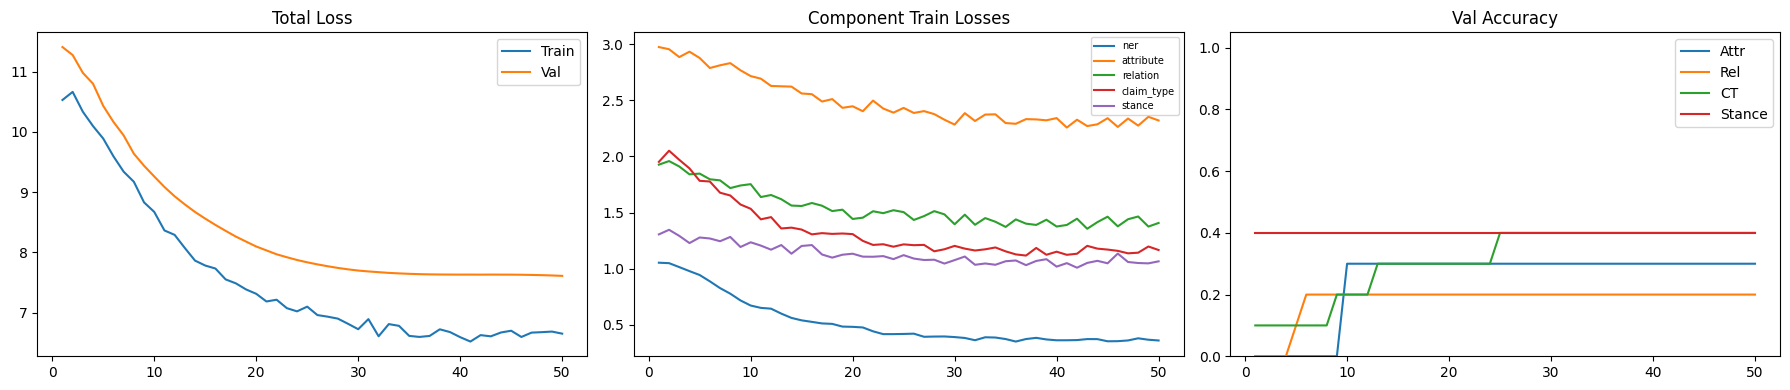

In [12]:
try:
    import matplotlib.pyplot as plt

    er = range(1, EPOCHS + 1)
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(er, [m["total"] for m in history["train"]], label="Train")
    axes[0].plot(er, [m["total"] for m in history["val"]],   label="Val")
    axes[0].set_title("Total Loss"); axes[0].legend()

    for task in ["ner", "attribute", "relation", "claim_type", "stance"]:
        axes[1].plot(er, [m[task] for m in history["train"]], label=task)
    axes[1].set_title("Component Train Losses"); axes[1].legend(fontsize=7)

    for metric, lbl in [("attribute_acc", "Attr"), ("relation_acc", "Rel"),
                        ("claim_type_acc", "CT"), ("stance_acc", "Stance")]:
        axes[2].plot(er, [m[metric] for m in history["val"]], label=lbl)
    axes[2].set_title("Val Accuracy"); axes[2].set_ylim(0, 1.05); axes[2].legend()

    plt.tight_layout()
    plt.savefig("training_curves_v4.png", dpi=120)
    plt.show()
except ImportError:
    print("matplotlib not available.")

In [13]:
@torch.no_grad()
def detailed_evaluation(model, loader):
    model.eval()
    all_ner_preds, all_ner_labels = [], []
    preds = {t: [] for t in ["attr", "rel", "ct", "stance"]}
    golds = {t: [] for t in ["attr", "rel", "ct", "stance"]}

    for batch in loader:
        batch  = {k: v.to(DEVICE) for k, v in batch.items()}

        with torch.amp.autocast(DEVICE_TYPE):
            logits = model(batch["input_ids"], batch["attention_mask"])

        ner_p = logits["ner_emissions"].argmax(-1)
        mask  = batch["ner_labels"] != NER_PAD_ID
        all_ner_preds.extend(ner_p[mask].cpu().tolist())
        all_ner_labels.extend(batch["ner_labels"][mask].cpu().tolist())

        for k, bk, lk in [("attr", "attr_label", "attr"), ("rel", "rel_label", "rel"),
                          ("ct", "ct_label", "ct"), ("stance", "stance_label", "stance")]:
            preds[k].extend(logits[lk].argmax(-1).cpu().tolist())
            golds[k].extend(batch[bk].cpu().tolist())

    def acc(p, g): return sum(a == b for a, b in zip(p, g)) / len(g)

    metrics = {
        "attribute_accuracy" : acc(preds["attr"],   golds["attr"]),
        "relation_accuracy"  : acc(preds["rel"],    golds["rel"]),
        "claim_type_accuracy": acc(preds["ct"],     golds["ct"]),
        "stance_accuracy"    : acc(preds["stance"], golds["stance"]),
    }

    print("\n===  Final Validation Metrics  ===")
    for k, v in metrics.items():
        print(f"  {k:<28}: {v:.4f}")

    if HAS_SEQEVAL:
        p_tags = [ID2NER.get(i, "O") for i in all_ner_preds]
        g_tags = [ID2NER.get(i, "O") for i in all_ner_labels]
        print("\n===  NER Report (seqeval)  ===")
        print(ner_report([g_tags], [p_tags], zero_division=0))

    return metrics

final_metrics = detailed_evaluation(model, val_loader)



===  Final Validation Metrics  ===
  attribute_accuracy          : 0.3000
  relation_accuracy           : 0.2000
  claim_type_accuracy         : 0.4000
  stance_accuracy             : 0.4000

===  NER Report (seqeval)  ===
              precision    recall  f1-score   support

      PERSON       0.77      1.00      0.87        17

   micro avg       0.77      1.00      0.87        17
   macro avg       0.77      1.00      0.87        17
weighted avg       0.77      1.00      0.87        17



In [ ]:
def decode_ner_entities(
    model, tokens: List[str], emissions: torch.Tensor,
    attention_mask: torch.Tensor,
    word_ids: Optional[List[Optional[int]]] = None,
) -> List[str]:
    """Returns a deduplicated list of player name strings."""
    bio_ids = emissions.argmax(-1).tolist()
    attn    = attention_mask.tolist()

    entities     = []
    current_toks = []

    for pos, (token, bio_id) in enumerate(zip(tokens, bio_ids)):
        # Skip padding
        if not attn[pos]:
            break
        # Skip special tokens: word_ids[pos] is None for [CLS]/[SEP]/padding
        if word_ids is not None and word_ids[pos] is None:
            continue

        tag = ID2NER.get(bio_id, "O")
        if tag == "B-PERSON":
            if current_toks:
                entities.append(tokenizer.convert_tokens_to_string(current_toks).strip())
            current_toks = [token]
        elif tag == "I-PERSON" and current_toks:
            current_toks.append(token)
        else:
            if current_toks:
                entities.append(tokenizer.convert_tokens_to_string(current_toks).strip())
            current_toks = []

    if current_toks:
        entities.append(tokenizer.convert_tokens_to_string(current_toks).strip())

    seen, unique = set(), []
    for e in entities:
        e = e.strip()
        if e and e not in seen:
            seen.add(e)
            unique.append(e)
    return unique

def compute_confidence(logits_dict: Dict) -> Dict[str, float]:
    per_task = {}
    product  = 1.0
    for key in ["attr", "rel", "ct", "stance"]:
        conf = F.softmax(logits_dict[key][0], dim=-1).max().item()
        per_task[key] = round(conf, 4)
        product *= conf
    per_task["aggregate"] = round(float(product ** (1.0 / 4)), 4)
    return per_task


In [ ]:
@torch.no_grad()
def predict(input_json: Dict[str, Any]) -> Dict[str, Any]:
    model.eval()
    text = input_json["text"]

    encoding = tokenizer(
        text, max_length=MAX_LENGTH, padding="max_length",
        truncation=True, return_offsets_mapping=True, return_tensors="pt",
    )
    word_ids_list = encoding.word_ids(batch_index=0)  
    encoding.pop("offset_mapping")
    input_ids      = encoding["input_ids"].to(DEVICE)
    attention_mask = encoding["attention_mask"].to(DEVICE)

    with torch.amp.autocast(DEVICE_TYPE):
        logits = model(input_ids, attention_mask)

    tokens   = tokenizer.convert_ids_to_tokens(input_ids[0].cpu().tolist())
    entities = decode_ner_entities(
        model, tokens, logits["ner_emissions"][0], attention_mask[0].cpu(),
        word_ids=word_ids_list,
    )

    attribute  = ID2ATTR[logits["attr"][0].argmax(-1).item()]
    relation   = ID2REL[logits["rel"][0].argmax(-1).item()]
    claim_type = ID2CT[logits["ct"][0].argmax(-1).item()]
    stance     = ID2STANCE[logits["stance"][0].argmax(-1).item()]
    confidence = compute_confidence(logits)

    return {
        "id"        : input_json.get("id"),
        "speaker"   : input_json.get("speaker"),
        "text"      : text,
        "entities"  : entities,
        "attribute" : attribute,
        "relation"  : relation,
        "claim_type": claim_type,
        "stance"    : stance,
        "confidence": confidence,
    }

def predict_batch(inputs: List[Dict]) -> List[Dict]:
    return [predict(inp) for inp in inputs]

def predict_text(text: str, speaker: str = "?", uid: int = 0) -> Dict:
    return predict({"id": uid, "speaker": speaker, "text": text})

In [16]:
test_inputs = [
    {"id": 1, "speaker": "A", "text": "Messi has more Ballon d'Ors than Ronaldo."},
    {"id": 2, "speaker": "B", "text": "Ronaldo scored over 900 career goals, the most in history."},
    {"id": 3, "speaker": "A", "text": "In my opinion, Neymar is more entertaining than Mbappe."},
]

print("=" * 75)
for inp in test_inputs:
    r = predict(inp)
    print(f"\nID {r['id']} | Speaker {r['speaker']}")
    print(f"  Text      : {r['text']}")
    print(f"  Entities  : {r['entities']}")
    print(f"  Attribute : {r['attribute']}")
    print(f"  Relation  : {r['relation']}")
    print(f"  ClaimType : {r['claim_type']}")
    print(f"  Stance    : {r['stance']}")
    print(f"  Confidence: {r['confidence']}")
    print("-" * 75)


ID 1 | Speaker A
  Text      : Messi has more Ballon d'Ors than Ronaldo.
  Entities  : ['Messi', 'Ronaldo']
  Attribute : individual_awards
  Relation  : equal
  ClaimType : statistical
  Stance    : support
  Confidence: {'attr': 0.2178, 'rel': 0.3035, 'ct': 0.6797, 'stance': 0.4021, 'aggregate': 0.3666}
---------------------------------------------------------------------------

ID 2 | Speaker B
  Text      : Ronaldo scored over 900 career goals, the most in history.
  Entities  : ['Ronaldo']
  Attribute : goals
  Relation  : greater_than
  ClaimType : statistical
  Stance    : support
  Confidence: {'attr': 0.2249, 'rel': 0.366, 'ct': 0.4924, 'stance': 0.688, 'aggregate': 0.4086}
---------------------------------------------------------------------------

ID 3 | Speaker A
  Text      : In my opinion, Neymar is more entertaining than Mbappe.
  Entities  : ['Neymar', 'Mbappe']
  Attribute : goals
  Relation  : greater_than
  ClaimType : statistical
  Stance    : support
  Confidence:

In [17]:
result = predict_text("Haaland's goals-per-game ratio in the Premier League beats every striker in history.")
print(json.dumps(result, indent=2))

{
  "id": 0,
  "speaker": "?",
  "text": "Haaland's goals-per-game ratio in the Premier League beats every striker in history.",
  "entities": [
    "Haa",
    "land",
    "Premier League",
    "striker"
  ],
  "attribute": "goals",
  "relation": "greater_than",
  "claim_type": "statistical",
  "stance": "support",
  "confidence": {
    "attr": 0.1428,
    "rel": 0.4062,
    "ct": 0.5952,
    "stance": 0.5605,
    "aggregate": 0.373
  }
}


In [ ]:
CHECKPOINT_DIR = "claim_extractor"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "model_1.pt"))
tokenizer.save_pretrained(CHECKPOINT_DIR)

config = {
    "model_name" : MODEL_NAME,
    "max_length" : MAX_LENGTH,
    "ner_tags"   : NER_TAGS,
    "attributes" : ATTRIBUTES,
    "relations"  : RELATIONS,
    "claim_types": CLAIM_TYPES,
    "stances"    : STANCES,
    "mlp_hidden" : MLP_HIDDEN,
    "dropout"    : DROPOUT,
}
with open(os.path.join(CHECKPOINT_DIR, "config.json"), "w") as f:
    json.dump(config, f, indent=2)

print(f"Saved to {CHECKPOINT_DIR}/")

Saved to claim_extractor_v7/


In [ ]:
import json, os, torch, torch.nn as nn, torch.nn.functional as F
from typing import Any, Dict, List
from transformers import AutoTokenizer, AutoModel

DEVICE_TYPE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE      = torch.device(DEVICE_TYPE)
CKPT_DIR    = "claim_extractor"

with open(os.path.join(CKPT_DIR, "config.json")) as f:
    _cfg = json.load(f)

_MODEL_NAME  = _cfg["model_name"]
_MAX_LENGTH  = _cfg["max_length"]
_MLP_HIDDEN  = _cfg["mlp_hidden"]
_DROPOUT     = _cfg["dropout"]
_NER_TAGS    = _cfg["ner_tags"]
_ATTRIBUTES  = _cfg["attributes"]
_RELATIONS   = _cfg["relations"]
_CLAIM_TYPES = _cfg["claim_types"]
_STANCES     = _cfg["stances"]

_NER_PAD_ID = -100
_ID2NER   = {i: t for i, t in enumerate(_NER_TAGS)}
_ID2ATTR  = {i: a for i, a in enumerate(_ATTRIBUTES)}
_ID2REL   = {i: r for i, r in enumerate(_RELATIONS)}
_ID2CT    = {i: c for i, c in enumerate(_CLAIM_TYPES)}
_ID2STANCE = {i: s for i, s in enumerate(_STANCES)}

_tokenizer = AutoTokenizer.from_pretrained(CKPT_DIR, use_fast=True)


class _ContextualAttentionPooling(nn.Module):
    def __init__(self, hidden):
        super().__init__()
        self.proj = nn.Sequential(nn.Linear(hidden, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    def forward(self, seq, mask):
        s = self.proj(seq).squeeze(-1).masked_fill(mask == 0, float("-inf"))
        return (torch.softmax(s, -1).unsqueeze(-1) * seq).sum(1)


class _ClassificationHead(nn.Module):
    def __init__(self, in_d, mid_d, out_d, drop):
        super().__init__()
        self.dense = nn.Linear(in_d, mid_d)
        self.norm  = nn.LayerNorm(mid_d)
        self.act   = nn.GELU()
        self.drops = nn.ModuleList([nn.Dropout(drop) for _ in range(5)])
        self.out   = nn.Linear(mid_d, out_d)
    def forward(self, x):
        x = self.act(self.norm(self.dense(x)))
        return sum(self.out(d(x)) for d in self.drops) / len(self.drops)


class _MultiTaskClaimModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder     = AutoModel.from_pretrained(_MODEL_NAME)
        h                = self.encoder.config.hidden_size
        self.dropout     = nn.Dropout(_DROPOUT)
        self.attention_pool    = _ContextualAttentionPooling(h)
        self.ner_linear  = nn.Linear(h, len(_NER_TAGS))
        self.attr_head   = _ClassificationHead(h, _MLP_HIDDEN, len(_ATTRIBUTES),  _DROPOUT)
        self.rel_head    = _ClassificationHead(h, _MLP_HIDDEN, len(_RELATIONS),   _DROPOUT)
        self.ct_head     = _ClassificationHead(h, _MLP_HIDDEN, len(_CLAIM_TYPES), _DROPOUT)
        self.stance_head = _ClassificationHead(h, _MLP_HIDDEN, len(_STANCES),     _DROPOUT)
    def forward(self, input_ids, attention_mask):
        seq    = self.encoder(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        pooled = self.dropout(self.attention_pool (seq, attention_mask))
        return {
            "ner_emissions": self.ner_linear(self.dropout(seq)),
            "attr"  : self.attr_head(pooled),
            "rel"   : self.rel_head(pooled),
            "ct"    : self.ct_head(pooled),
            "stance": self.stance_head(pooled),
        }


_infer_model = _MultiTaskClaimModel().to(DEVICE)
_infer_model.load_state_dict(
    torch.load(os.path.join(CKPT_DIR, "model_1.pt"), map_location=DEVICE)
)
_infer_model.eval()
print(f"Loaded model from {CKPT_DIR}/ on {DEVICE}")


def _decode_ner(tokens, emissions, attention_mask, word_ids=None):
    attn    = attention_mask.tolist()
    bio_ids = emissions.argmax(-1).tolist()
    entities, cur = [], []
    for pos, (tok, bid) in enumerate(zip(tokens, bio_ids)):
        if not attn[pos]:
            break
        if word_ids is not None and word_ids[pos] is None:
            continue
        tag = _ID2NER.get(bid, "O")
        if tag == "B-PERSON":
            if cur: entities.append(_tokenizer.convert_tokens_to_string(cur).strip())
            cur = [tok]
        elif tag == "I-PERSON" and cur:
            cur.append(tok)
        else:
            if cur: entities.append(_tokenizer.convert_tokens_to_string(cur).strip())
            cur = []
    if cur: entities.append(_tokenizer.convert_tokens_to_string(cur).strip())
    seen, uniq = set(), []
    for e in entities:
        e = e.strip()
        if e and e not in seen: seen.add(e); uniq.append(e)
    return uniq


@torch.no_grad()
def infer(text: str, speaker: str = "?", uid: int = 0) -> Dict[str, Any]:
    enc = _tokenizer(
        text, max_length=_MAX_LENGTH, padding="max_length",
        truncation=True, return_offsets_mapping=True, return_tensors="pt",
    )
    _word_ids = enc.word_ids(batch_index=0)
    enc.pop("offset_mapping")
    ids  = enc["input_ids"].to(DEVICE)
    mask = enc["attention_mask"].to(DEVICE)

    with torch.amp.autocast(DEVICE_TYPE):
        logits = _infer_model(ids, mask)

    tokens   = _tokenizer.convert_ids_to_tokens(ids[0].cpu().tolist())
    entities = _decode_ner(tokens, logits["ner_emissions"][0], mask[0].cpu(), word_ids=_word_ids)

    conf = {}
    prod = 1.0
    for k in ["attr", "rel", "ct", "stance"]:
        c = F.softmax(logits[k][0], dim=-1).max().item()
        conf[k] = round(c, 4); prod *= c
    conf["aggregate"] = round(prod ** 0.25, 4)

    return {
        "id"        : uid,
        "speaker"   : speaker,
        "text"      : text,
        "entities"  : entities,
        "attribute" : _ID2ATTR[logits["attr"][0].argmax(-1).item()],
        "relation"  : _ID2REL[logits["rel"][0].argmax(-1).item()],
        "claim_type": _ID2CT[logits["ct"][0].argmax(-1).item()],
        "stance"    : _ID2STANCE[logits["stance"][0].argmax(-1).item()],
        "confidence": conf,
    }


_test_texts = [
    "Messi has more Ballon d'Ors than Ronaldo.",
    "Ronaldo scored over 900 career goals, the most in history.",
    "In my opinion, Neymar is more entertaining than Mbappe.",
    "Neuer won more UCLs than Buffon"
]
print("=" * 75)
for i, t in enumerate(_test_texts, 1):
    r = infer(t, uid=i)
    print(f"\n[{i}] {r['text']}")
    print(f"  entities  : {r['entities']}")
    print(f"  attribute : {r['attribute']}  |  relation : {r['relation']}")
    print(f"  claim_type: {r['claim_type']}  |  stance   : {r['stance']}")
    print(f"  confidence: {r['confidence']}")
    print("-" * 75)


Loaded model from claim_extractor_v7/ on cuda

[1] Messi has more Ballon d'Ors than Ronaldo.
  entities  : ['Messi', 'Ronaldo']
  attribute : individual_awards  |  relation : equal
  claim_type: statistical  |  stance   : support
  confidence: {'attr': 0.2178, 'rel': 0.3035, 'ct': 0.6797, 'stance': 0.4021, 'aggregate': 0.3666}
---------------------------------------------------------------------------

[2] Ronaldo scored over 900 career goals, the most in history.
  entities  : ['Ronaldo']
  attribute : goals  |  relation : greater_than
  claim_type: statistical  |  stance   : support
  confidence: {'attr': 0.2249, 'rel': 0.366, 'ct': 0.4924, 'stance': 0.688, 'aggregate': 0.4086}
---------------------------------------------------------------------------

[3] In my opinion, Neymar is more entertaining than Mbappe.
  entities  : ['Neymar', 'Mbappe']
  attribute : goals  |  relation : greater_than
  claim_type: statistical  |  stance   : support
  confidence: {'attr': 0.1903, 'rel': 0.41